## **Prompt-based Image Generation using Diffusion Models for Data Augmentation (with FlowAlign)**

*N. Bacherotti, L. Ceccarelli, M. Meazzini*

### Setup and Global Configuration

In [1]:
from pathlib import Path
import copy
import gc
import json
import math
import os
import random
import sys
import time
import re

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from scipy.stats import binomtest

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from diffusers import DiffusionPipeline
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
import seaborn as sns
from sklearn.calibration import CalibrationDisplay
from torch.utils.data import ConcatDataset, DataLoader, Dataset, Subset
from torchvision import transforms
from torchvision.datasets import OxfordIIITPet
from torchvision.models import resnet18
from torchvision.utils import save_image
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BlipForConditionalGeneration,
    BlipProcessor,
)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PROJECT_DIR = Path.cwd().resolve()
if PROJECT_DIR.name != "seai_project":
    PROJECT_DIR = PROJECT_DIR / "seai_project"

FLOWALIGN_PATH = PROJECT_DIR / "FlowAlign"
if str(FLOWALIGN_PATH) not in sys.path:
    sys.path.insert(0, str(FLOWALIGN_PATH))

BASE_DIR = PROJECT_DIR / "dataset"
DATA_ROOT = BASE_DIR / "oxford_pets"
SPLITS_DIR = BASE_DIR / "splits"

TEST_MODE = True         
RUN_GENERATION = True   
RUN_EXP_1 = True
MODEL_NAME = "flowalign" 
N_FOLDS = 5

if TEST_MODE:
    N_MAJORITY_TRAIN = 100
    N_MINORITY_TRAIN = 20
    NUM_EPOCHS = 3
    PATIENCE = 3
    RUN_TAG = "TEST"
else:
    N_MAJORITY_TRAIN = 4000
    N_MINORITY_TRAIN = 400
    NUM_EPOCHS = 50
    PATIENCE = 10
    RUN_TAG = "FULL"

SPLIT_PATH = SPLITS_DIR / f"split_indices_{RUN_TAG}_seed43.npz"
CV_FOLDS_PATH = SPLITS_DIR / f"cv_folds_{RUN_TAG}_seed43.npz"

K_FOLD_OUTPUT_DIR = BASE_DIR / "k_fold_outputs" / f"{MODEL_NAME}_{RUN_TAG}"
K_FOLD_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASSIC_AUG_DIR = BASE_DIR / f"classic_augmented_baseline_flowalign_{RUN_TAG}_splitseed43"
BASELINE_CV_DIR = K_FOLD_OUTPUT_DIR / "baseline_classic_balanced"
FLOWALIGN_CV_DIR = K_FOLD_OUTPUT_DIR / "flowalign"

JSON_PATH = BASE_DIR / "captions" / f"blip_qwen_captions_{MODEL_NAME}_{RUN_TAG}.json"
FLOWALIGN_IN_DIR = BASE_DIR / f"{MODEL_NAME}_inputs_{RUN_TAG}"
FLOWALIGN_OUT_DIR = BASE_DIR / f"{MODEL_NAME}_outputs_{RUN_TAG}" / "edited"

if RUN_GENERATION:
    FLOWALIGN_OUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR = BASE_DIR / f"classifier_outputs_{MODEL_NAME}_{RUN_TAG}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Model Name: {MODEL_NAME}")
print(f"Mode: {RUN_TAG}")
print(f"Generation Enabled: {RUN_GENERATION}")
print(f"Epochs: {NUM_EPOCHS}")

Model Name: flowalign
Mode: TEST
Generation Enabled: True
Epochs: 3


In [3]:
FLOWALIGN_IMG_SIZE = 1024 
IMG_SIZE = 224       
BATCH_SIZE = 32
NUM_WORKERS = 0
SEED = 42

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

class_names = ["dog", "cat"]
num_classes = 2

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

classic_offline_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)
])



eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

In [4]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


### Dataset Preparation and Imbalanced Split

In [5]:
class BinaryPetWrapper(Dataset):
    """
    Takes images from Oxford Pets (37 classes) and dynamically maps them to 2 classes:
    0 -> Dog (Majority)
    1 -> Cat (Minority)
    """
    def __init__(self, concat_dataset, indices, transform=None):
        self.dataset = concat_dataset
        self.indices = list(indices)
        self.transform = transform
        
        self.cat_breeds = [
            'Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British Shorthair', 
            'Egyptian Mau', 'Maine Coon', 'Persian', 'Ragdoll', 'Russian Blue', 
            'Siamese', 'Sphynx'
        ]
        
        classes = self.dataset.datasets[0].classes
        self.cat_indices = {classes.index(b) for b in self.cat_breeds}

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        image, original_label = self.dataset[real_idx]
        
        new_label = 1 if original_label in self.cat_indices else 0
        
        if self.transform:
            image = self.transform(image)
            
        return image, new_label

In [6]:
print("Downloading/Verifying dataset...")

base_trainval = OxfordIIITPet(root=DATA_ROOT, split="trainval", download=True)
base_test = OxfordIIITPet(root=DATA_ROOT, split="test", download=True)
full_dataset = ConcatDataset([base_trainval, base_test])

all_targets = np.concatenate([base_trainval._labels, base_test._labels])
classes = base_trainval.classes

cat_class_indices = {classes.index(b) for b in [
    "Abyssinian", "Bengal", "Birman", "Bombay", "British Shorthair",
    "Egyptian Mau", "Maine Coon", "Persian", "Ragdoll", "Russian Blue",
    "Siamese", "Sphynx"
]}
binary_targets = np.array([1 if t in cat_class_indices else 0 for t in all_targets])

if not SPLIT_PATH.exists():
    raise FileNotFoundError(f"Split not found! Missing: {SPLIT_PATH}")

print(f"Loading existing split from {SPLIT_PATH}...")
split = np.load(SPLIT_PATH)

majority_train_idx = split["majority_train_idx"]
minority_train_idx = split["minority_train_idx"]
majority_test_idx = split["majority_test_idx"]
minority_test_idx = split["minority_test_idx"]

print("Available dogs in train:", len(majority_train_idx))
print("Available cats in train:", len(minority_train_idx))

Downloading/Verifying dataset...
Loading existing split from /workspace/seai_project/dataset/splits/split_indices_TEST_seed43.npz...
Available dogs in train: 100
Available cats in train: 20


In [7]:
train_idx = np.concatenate([majority_train_idx, minority_train_idx])
test_idx = np.concatenate([majority_test_idx, minority_test_idx])

cv_indices = train_idx.copy()
cv_labels = binary_targets[cv_indices]

train_dataset = BinaryPetWrapper(full_dataset, train_idx, transform=train_transform)
test_dataset = BinaryPetWrapper(full_dataset, test_idx, transform=eval_transform)

assert not set(train_idx) & set(test_idx)

print("Train:", np.bincount(binary_targets[train_idx]))
print("Fixed test:", np.bincount(binary_targets[test_idx]))

Train: [100  20]
Fixed test: [40 40]


In [8]:
if not CV_FOLDS_PATH.exists():
    raise FileNotFoundError(f"CV Folds not found! Missing: {CV_FOLDS_PATH}")

print(f"Loading CV folds from {CV_FOLDS_PATH}...")
cv_folds = np.load(CV_FOLDS_PATH)

all_cv_val = []
for fold in range(1, N_FOLDS + 1): # N_FOLDS = 5
    tr = cv_folds[f"train_{fold}"]
    va = cv_folds[f"val_{fold}"]
    
    assert not set(tr) & set(va)
    all_cv_val.extend(va.tolist())
    
    print(f"Fold {fold}: train {np.bincount(binary_targets[tr])} | val {np.bincount(binary_targets[va])}")

assert set(all_cv_val) == set(cv_indices.tolist())

Loading CV folds from /workspace/seai_project/dataset/splits/cv_folds_TEST_seed43.npz...
Fold 1: train [80 16] | val [20  4]
Fold 2: train [80 16] | val [20  4]
Fold 3: train [80 16] | val [20  4]
Fold 4: train [80 16] | val [20  4]
Fold 5: train [80 16] | val [20  4]


In [9]:
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS, 
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS, 
    pin_memory=torch.cuda.is_available()
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))
print("✅ Dataset successfully loaded and artificially imbalanced!")

Train batches: 4
Test batches: 3
✅ Dataset successfully loaded and artificially imbalanced!


### Utilities Definition (Training, Metrics, and Plots)

In [10]:
def run_epoch(model, loader, criterion, optimizer=None):
    """
    Run one complete epoch.

    If an optimizer is provided, the model is trained.
    Otherwise, the model is evaluated without gradient updates.
    """

    training = optimizer is not None

    if training:
        model.train()
    else:
        model.eval()

    running_loss = 0.0

    all_targets = []
    all_preds = []

    for images, targets in loader:

        images = images.to(DEVICE)
        targets = targets.to(DEVICE)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):

            logits = model(images)

            loss = criterion(logits, targets)

            if training:
                loss.backward()
                optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = logits.argmax(dim=1)

        all_targets.extend(
            targets.detach().cpu().numpy()
        )

        all_preds.extend(
            preds.detach().cpu().numpy()
        )

    loss = running_loss / len(loader.dataset)

    accuracy = accuracy_score(
        all_targets,
        all_preds
    )

    balanced_accuracy = balanced_accuracy_score(
        all_targets,
        all_preds
    )

    _, _, macro_f1, _ = precision_recall_fscore_support(
        all_targets,
        all_preds,
        average="macro",
        zero_division=0
    )

    return {
        "loss": loss,
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "macro_f1": macro_f1
    }

In [11]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    num_epochs,
    patience,
    model_name="best_model.pth"
):
    """
    Train the model using early stopping based on validation macro-F1.

    The checkpoint with the lowest validation loss is saved
    and restored at the end of training.
    """

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": [],
        "train_balanced_accuracy": [],
        "val_balanced_accuracy": [],
        "train_macro_f1": [],
        "val_macro_f1": []
    }

    best_state = copy.deepcopy(
        model.state_dict()
    )

    best_val_f1 = 0.0  
    best_epoch = 0
    no_improvement = 0

    for epoch in range(num_epochs):

        start = time.time()

        train_metrics = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        val_metrics = run_epoch(
            model,
            val_loader,
            criterion
        )

        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["train_accuracy"].append(train_metrics["accuracy"])
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["train_balanced_accuracy"].append(train_metrics["balanced_accuracy"])
        history["val_balanced_accuracy"].append(val_metrics["balanced_accuracy"])
        history["train_macro_f1"].append(train_metrics["macro_f1"])
        history["val_macro_f1"].append(val_metrics["macro_f1"])

        print(
            f"Epoch {epoch + 1:02d}/{num_epochs} | "
            f"{time.time() - start:.1f}s | "
            f"Train loss {train_metrics['loss']:.4f} | "
            f"Val loss {val_metrics['loss']:.4f} | "
            f"Train F1 {train_metrics['macro_f1']:.4f} | "
            f"Val F1 {val_metrics['macro_f1']:.4f}"
        )

        if val_metrics["macro_f1"] > best_val_f1:

            best_val_f1 = val_metrics["macro_f1"]
            best_epoch = epoch + 1

            best_state = copy.deepcopy(
                model.state_dict()
            )

            torch.save(
                best_state,
                OUTPUT_DIR / model_name
            )

            no_improvement = 0
            print("Best model saved (F1 improved)")

        else:
            no_improvement += 1

        if no_improvement >= patience:
            print("Early stopping (No F1 improvement)")
            break

    model.load_state_dict(best_state)

    print(
        f"Best epoch: {best_epoch} | "
        f"Best val F1: {best_val_f1:.4f}"
    )

    return model, history

In [12]:
def plot_and_save_history(history, output_dir, fold):
    output_dir = Path(output_dir)
    with open(output_dir / f"history_fold_{fold}.json", "w") as f:
        json.dump(history, f, indent=4)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].plot(history["train_loss"], label="Train Loss")
    axes[0].plot(history["val_loss"], label="Val Loss")
    axes[0].set_title(f"Fold {fold} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    
    axes[1].plot(history["train_macro_f1"], label="Train Macro F1")
    axes[1].plot(history["val_macro_f1"], label="Val Macro F1")
    axes[1].set_title(f"Fold {fold} - Macro F1")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    
    fig.tight_layout()
    fig.savefig(output_dir / f"learning_curves_fold_{fold}.png", dpi=200)
    plt.close(fig)

def plot_cv_boxplot(cv_df, title, output_dir):
    plt.figure(figsize=(8, 5))
    metrics_to_plot = ["balanced_accuracy", "macro_f1", "roc_auc", "pr_auc"]
    sns.boxplot(data=cv_df[metrics_to_plot])
    plt.title(title)
    plt.ylabel("Score")
    plt.tight_layout()
    plt.savefig(Path(output_dir) / "cv_metrics_boxplot.png", dpi=200)
    plt.close()

In [13]:
def build_model(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(DEVICE)

In [14]:
@torch.no_grad()
def predict_dataset(model, loader):
    """
    Generate ground-truth labels, predicted labels and class probabilities
    for all samples contained in a DataLoader.
    """

    model.eval()

    y_true = []
    y_pred = []
    y_prob = []

    for images, targets in loader:
        images = images.to(DEVICE)

        logits = model(images)
        probs = torch.softmax(logits, dim=1)

        preds = probs.argmax(dim=1)

        y_true.extend(targets.numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

    return (
        np.array(y_true),
        np.array(y_pred),
        np.array(y_prob)
    )

In [15]:
def evaluate(y_true, y_pred, y_prob, class_names, split):
    """Compute classification metrics. Minority class is label 1."""

    accuracy = accuracy_score(y_true, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_true, y_pred)

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    metrics = {
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1
    }

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=np.arange(len(class_names)), zero_division=0
    )

    for i, cls in enumerate(class_names):
        metrics[f"{cls}_precision"] = precision[i]
        metrics[f"{cls}_recall"] = recall[i]
        metrics[f"{cls}_f1"] = f1[i]
        metrics[f"{cls}_support"] = int(support[i])

    minority_probability = y_prob[:, 1]

    metrics["roc_auc"] = roc_auc_score(y_true, minority_probability)
    metrics["pr_auc"] = average_precision_score(y_true, minority_probability)

    print(f"\n===== {split.upper()} =====")
    print(f"Accuracy: {accuracy:.4f} | Balanced Accuracy: {balanced_accuracy:.4f} | Macro Precision: {macro_precision:.4f} | Macro Recall: {macro_recall:.4f} | Macro F1: {macro_f1:.4f}")
    print(f"ROC-AUC: {metrics['roc_auc']:.4f} | PR-AUC: {metrics['pr_auc']:.4f}")

    print(classification_report(
        y_true, y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    ))

    return metrics



In [16]:
def fold_metrics(y, pred, prob):
    prob_cat = prob[:, 1] if np.asarray(prob).ndim == 2 else np.asarray(prob)
    _, recall, _, _ = precision_recall_fscore_support(y, pred, labels=[0, 1], zero_division=0)

    return {
        "accuracy": accuracy_score(y, pred),
        "balanced_accuracy": balanced_accuracy_score(y, pred),
        "macro_f1": f1_score(y, pred, average="macro"),
        "roc_auc": roc_auc_score(y, prob_cat),
        "pr_auc": average_precision_score(y, prob_cat),
        "dog_recall": recall[0],
        "cat_recall": recall[1]
    }

In [17]:
def save_oof_artifacts(name, y_true, y_pred, y_prob, sample_idx, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    metrics = fold_metrics(y_true, y_pred, y_prob)
    pd.DataFrame([metrics]).to_csv(output_dir / "oof_metrics.csv", index=False)

    df_preds = pd.DataFrame({
        "sample_idx": sample_idx,
        "y_true": y_true,
        "y_pred": y_pred,
        "prob_cat": y_prob
    })
    df_preds.to_csv(output_dir / "oof_predictions.csv", index=False)
    
    errors_df = df_preds[df_preds["y_true"] != df_preds["y_pred"]].copy()
    errors_df["error_type"] = np.where(errors_df["y_pred"] == 1, "False Positive", "False Negative")
    errors_df.to_csv(output_dir / "oof_misclassified_samples.csv", index=False)

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(f"{name} - Aggregated 5-Fold OOF")
    fig.tight_layout()
    fig.savefig(output_dir / "oof_confusion_matrix.png", dpi=200)
    plt.close(fig)

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.3f}")
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} - 5-Fold OOF ROC")
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_dir / "oof_roc_curve.png", dpi=200)
    plt.close()

    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    plt.figure(figsize=(7, 6))
    plt.plot(recall, precision, label=f"AP = {metrics['pr_auc']:.3f}")
    plt.axhline(np.mean(y_true == 1), linestyle="--", label="Positive prevalence")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{name} - 5-Fold OOF Precision-Recall")
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_dir / "oof_pr_curve.png", dpi=200)
    plt.close()
    
    fig, ax = plt.subplots(figsize=(6, 6))
    CalibrationDisplay.from_predictions(y_true, y_prob, n_bins=10, ax=ax, name=name)
    ax.set_title(f"{name} - Calibration Curve")
    fig.tight_layout()
    fig.savefig(output_dir / "oof_calibration_curve.png", dpi=200)
    plt.close(fig)

In [18]:
def save_test_artifacts(name, y_true, y_pred, y_prob, sample_idx, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    df_preds = pd.DataFrame({
        "sample_idx": sample_idx,
        "y_true": y_true,
        "y_pred": y_pred,
        "prob_cat": y_prob
    })
    errors_df = df_preds[df_preds["y_true"] != df_preds["y_pred"]].copy()
    errors_df["error_type"] = np.where(errors_df["y_pred"] == 1, "False Positive", "False Negative")
    errors_df.to_csv(output_dir / f"test_misclassified_{name.lower()}.csv", index=False)

    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(f"{name} - Ensemble Test Set CM")
    fig.tight_layout()
    fig.savefig(output_dir / f"test_confusion_matrix_{name.lower()}.png", dpi=200)
    plt.close(fig)
    
    optimal_bins = 10 if len(y_true) > 100 else 5
    
    fig, ax = plt.subplots(figsize=(6, 6))
    CalibrationDisplay.from_predictions(y_true, y_prob, n_bins=optimal_bins, ax=ax, name=f"{name} Ensemble")
    ax.set_title(f"{name} - Test Set Calibration Curve")
    fig.tight_layout()
    fig.savefig(output_dir / f"test_calibration_curve_{name.lower()}.png", dpi=200)
    plt.close(fig)

### Experiment 1: Baseline Training with Balanced Classical Data Augmentation

In [19]:
class ClassicAugmentedPathsDataset(Dataset):
    def __init__(self, paths, transform=None):
        self.paths, self.transform = list(paths), transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, 1


def get_classic_source_idx(path):
    match = re.fullmatch(r"pet_train_(\d+)_classic_\d+\.jpg", Path(path).name)
    if match is None:
        raise ValueError(f"Unexpected classic augmentation filename: {path}")
    return int(match.group(1))


def prepare_classic_augmentation():
    CLASSIC_AUG_DIR.mkdir(parents=True, exist_ok=True)

    n_majority, n_minority = len(majority_train_idx), len(minority_train_idx)
    n_needed = n_majority - n_minority
    base_variants, remainder = divmod(n_needed, n_minority)
    expected_paths = []

    for i, source_idx in enumerate(minority_train_idx.tolist()):
        raw_image, _ = full_dataset[source_idx]
        raw_image = raw_image.convert("RGB")
        n_variants = base_variants + (1 if i < remainder else 0)

        for variant in range(1, n_variants + 1):
            out_path = CLASSIC_AUG_DIR / f"pet_train_{source_idx}_classic_{variant}.jpg"
            expected_paths.append(out_path)

            if out_path.exists():
                continue

            local_seed = SEED + source_idx * 1000 + variant
            random.seed(local_seed)
            np.random.seed(local_seed % (2**32 - 1))
            torch.manual_seed(local_seed)

            classic_offline_transform(raw_image).save(out_path, quality=95)

    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    assert len(expected_paths) == n_needed
    assert {get_classic_source_idx(p) for p in expected_paths} == set(minority_train_idx.tolist())

    print(f"Classic augmentation pool: {len(expected_paths)} images | folder: {CLASSIC_AUG_DIR}")
    return sorted(expected_paths)

In [20]:
if RUN_EXP_1:
    BASELINE_CV_DIR.mkdir(parents=True, exist_ok=True)

    baseline_results = []
    baseline_oof_pred = np.full(len(cv_indices), -1)
    baseline_oof_prob = np.full(len(cv_indices), np.nan)
    cv_position = {int(idx): pos for pos, idx in enumerate(cv_indices)}

    cv_folds = np.load(CV_FOLDS_PATH)
    all_classic_paths = prepare_classic_augmentation()

    for fold in range(1, N_FOLDS + 1):
        fold_train_idx = cv_folds[f"train_{fold}"]
        fold_val_idx = cv_folds[f"val_{fold}"]

        train_counts = np.bincount(binary_targets[fold_train_idx], minlength=2)
        val_counts = np.bincount(binary_targets[fold_val_idx], minlength=2)

        train_cat_ids = set(fold_train_idx[binary_targets[fold_train_idx] == 1].tolist())
        val_cat_ids = set(fold_val_idx[binary_targets[fold_val_idx] == 1].tolist())

        fold_classic_paths = [p for p in all_classic_paths if get_classic_source_idx(p) in train_cat_ids]

        assert not any(get_classic_source_idx(p) in val_cat_ids for p in fold_classic_paths)
        assert train_counts[1] + len(fold_classic_paths) == train_counts[0], f"Fold {fold} is not balanced."

        real_train = BinaryPetWrapper(full_dataset, fold_train_idx, transform=train_transform)
        classic_train = ClassicAugmentedPathsDataset(fold_classic_paths, transform=train_transform)
        balanced_train = ConcatDataset([real_train, classic_train])
        fold_val = BinaryPetWrapper(full_dataset, fold_val_idx, transform=eval_transform)

        train_loader_fold = DataLoader(balanced_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
        val_loader_fold = DataLoader(fold_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

        OUTPUT_DIR = BASELINE_CV_DIR / f"fold_{fold}"
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

        model = build_model(SEED + fold)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

        balanced_counts = [int(train_counts[0]), int(train_counts[1] + len(fold_classic_paths))]
        print(f"\nFold {fold}: real {train_counts.tolist()} | classic +{len(fold_classic_paths)} cats | balanced {balanced_counts} | val {val_counts.tolist()}")

        model, history = train_model(model, train_loader_fold, val_loader_fold, criterion, optimizer, NUM_EPOCHS, PATIENCE)
        plot_and_save_history(history, OUTPUT_DIR, fold)

        y, pred, prob = predict_dataset(model, val_loader_fold)
        metrics = fold_metrics(y, pred, prob)
        baseline_results.append({"fold": fold, **metrics})

        pos = np.array([cv_position[int(i)] for i in fold_val_idx])
        baseline_oof_pred[pos] = pred
        baseline_oof_prob[pos] = prob[:, 1]

        print(f"Fold {fold}: F1 {metrics['macro_f1']:.4f} | AUC {metrics['roc_auc']:.4f}")

        del model, optimizer, criterion
        gc.collect()
        torch.cuda.empty_cache()

Classic augmentation pool: 80 images | folder: /workspace/seai_project/dataset/classic_augmented_baseline_flowalign_TEST_splitseed43

Fold 1: real [80, 16] | classic +64 cats | balanced [80, 80] | val [20, 4]
Epoch 01/3 | 1.3s | Train loss 1.4811 | Val loss 22.0527 | Train F1 0.5118 | Val F1 0.1429
Best model saved (F1 improved)
Epoch 02/3 | 1.0s | Train loss 0.8131 | Val loss 5.3210 | Train F1 0.5145 | Val F1 0.2448
Best model saved (F1 improved)
Epoch 03/3 | 1.0s | Train loss 0.6711 | Val loss 4.8704 | Train F1 0.5614 | Val F1 0.4545
Best model saved (F1 improved)
Best epoch: 3 | Best val F1: 0.4545
Fold 1: F1 0.4545 | AUC 0.3375

Fold 2: real [80, 16] | classic +64 cats | balanced [80, 80] | val [20, 4]
Epoch 01/3 | 1.0s | Train loss 1.7027 | Val loss 61.8302 | Train F1 0.4537 | Val F1 0.1429
Best model saved (F1 improved)
Epoch 02/3 | 1.0s | Train loss 0.8353 | Val loss 38.2848 | Train F1 0.5124 | Val F1 0.1429
Epoch 03/3 | 1.0s | Train loss 0.6339 | Val loss 5.2618 | Train F1 0.63

In [21]:
if RUN_EXP_1:
    baseline_cv_df = pd.DataFrame(baseline_results)
    display(baseline_cv_df)

    for m in ["balanced_accuracy", "macro_f1", "roc_auc", "pr_auc", "dog_recall", "cat_recall"]:
        print(f"{m}: {baseline_cv_df[m].mean():.4f} ± {baseline_cv_df[m].std():.4f}")

    baseline_cv_df.to_csv(BASELINE_CV_DIR / "cv_results.csv", index=False)

    np.savez(
        BASELINE_CV_DIR / "oof_predictions.npz",
        y_true=cv_labels,
        pred=baseline_oof_pred,
        prob=baseline_oof_prob
    )

,fold,accuracy,balanced_accuracy,macro_f1,roc_auc,pr_auc,dog_recall,cat_recall
0,1,0.833333,0.500,0.454545,0.33750,0.155871,1.00,0.00
1,2,0.291667,0.575,0.290435,0.81875,0.380754,0.15,1.00
2,3,0.250000,0.450,0.250000,0.18750,0.129576,0.15,0.75
3,4,0.791667,0.475,0.441860,0.47500,0.260784,0.95,0.00
4,5,0.666667,0.500,0.494737,0.47500,0.190892,0.75,0.25


balanced_accuracy: 0.5000 ± 0.0468
macro_f1: 0.3863 ± 0.1087
roc_auc: 0.4588 ± 0.2337
pr_auc: 0.2236 ± 0.1007
dog_recall: 0.6000 ± 0.4213
cat_recall: 0.4000 ± 0.4541


In [22]:
if RUN_EXP_1:
    assert np.all(baseline_oof_pred >= 0) and np.all(np.isfinite(baseline_oof_prob))

    save_oof_artifacts(
        "Baseline",
        cv_labels,
        baseline_oof_pred,
        baseline_oof_prob,
        cv_indices,
        BASELINE_CV_DIR
    )

In [23]:
# Load baseline OOF predictions if baseline was not run in this session  

baseline_oof_path = BASELINE_CV_DIR / "oof_predictions.npz"

if "baseline_oof_pred" not in globals() or "baseline_oof_prob" not in globals():

    if not baseline_oof_path.exists():
        raise FileNotFoundError(
            f"Baseline OOF predictions not found at:\n{baseline_oof_path}\n"
            "Run the baseline first with RUN_EXP_1 = True."
        )

    baseline_oof = np.load(baseline_oof_path)

    baseline_oof_pred = baseline_oof["pred"]
    baseline_oof_prob = baseline_oof["prob"]

    # Safety checks
    if "y_true" in baseline_oof.files:
        assert np.array_equal(
            baseline_oof["y_true"],
            cv_labels
        ), "Saved baseline OOF labels do not match current CV labels."

    assert len(baseline_oof_pred) == len(cv_indices)
    assert len(baseline_oof_prob) == len(cv_indices)

    print("Baseline OOF predictions loaded successfully.")
    print("Path:", baseline_oof_path)

### Textual Data Augmentation (Vision-Language Model and LLM)

In [24]:
OUTPUT_FILE = str(JSON_PATH)
MAIN_SUBJECT = "cat"

if RUN_GENERATION:
    JSON_PATH.parent.mkdir(parents=True, exist_ok=True)
    print("Generation output:", JSON_PATH)
else:
    print("Generation skipped: existing BLIP/Qwen/flowalign data will be reused.")

Generation output: /workspace/seai_project/dataset/captions/blip_qwen_captions_flowalign_TEST.json


In [25]:
if RUN_GENERATION:

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Hardware check: Using '{device}'\n")

    if device.type == "cpu":
        raise SystemError("CRITICAL ERROR: PyTorch cannot detect the GPU.")

    blip_id = "Salesforce/blip-image-captioning-large"
    print(f"Loading {blip_id} (Vision)...")
    blip_processor = BlipProcessor.from_pretrained(blip_id)
    blip_model = BlipForConditionalGeneration.from_pretrained(blip_id, torch_dtype=torch.float16).to(device)
    blip_model.eval()

    llm_id = "Qwen/Qwen2.5-7B-Instruct"
    print(f"Loading {llm_id} (Text Augmentation)...")
    llm_tokenizer = AutoTokenizer.from_pretrained(llm_id)
    llm_model = AutoModelForCausalLM.from_pretrained(
        llm_id, 
        torch_dtype=torch.float16, 
        device_map="cuda",
        low_cpu_mem_usage=True,
    )
    llm_model.eval()

    print("BLIP and Qwen loaded.")
else:
    print("BLIP and Qwen skipped.")


Hardware check: Using 'cuda'

Loading Salesforce/blip-image-captioning-large (Vision)...


Loading weights: 100%|██████████| 616/616 [00:00<00:00, 4578.74it/s]


Loading Qwen/Qwen2.5-7B-Instruct (Text Augmentation)...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 339/339 [00:00<00:00, 1490.20it/s]


BLIP and Qwen loaded.


In [26]:
def generate_variants_local(original_caption, main_subject, num_variants=5):
    """
    Generates text variants using the local LLM via ChatML format.
    """
    system_prompt = (
        "You are an AI assistant specialized in data augmentation. "
        "Your task is to generate diverse variants of an input caption to balance a dataset. "
        "Keep captions short (max 12 words) and simple."
    )
    
    user_prompt = (
        f"Generate exactly {num_variants} distinct variants of this caption: '{original_caption}'.\n"
        f"RULE 1: The core subject MUST remain '{main_subject}'.\n"
        f"RULE 2: Change ONLY attributes like colors, adjectives, or background.\n"
        f"RULE 3: Output ONLY a numbered list from 1 to {num_variants}. Do not write any other introductory text."
    )
    
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": user_prompt}
    ]
    
    text_prompt = llm_tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )
    
    inputs = llm_tokenizer([text_prompt], return_tensors="pt").to(device)
    
    with torch.no_grad():
        generated_ids = llm_model.generate(
            **inputs,
            max_new_tokens=150,
            temperature=0.7,
            do_sample=True,
            pad_token_id=llm_tokenizer.eos_token_id
        )
        
    response_ids = [
        output_ids[len(input_ids):] 
        for input_ids, output_ids in zip(inputs.input_ids, generated_ids)
    ]
    response_text = llm_tokenizer.batch_decode(response_ids, skip_special_tokens=True)[0]
    
    variants = []
    for line in response_text.split('\n'):
        line = line.strip()
        if line and line[0].isdigit():
            clean_text = line.split('.', 1)[-1].strip()
            if clean_text:
                variants.append(clean_text)
                
    return variants

print("✅ Text augmentation engine initialized.")

✅ Text augmentation engine initialized.


In [27]:
if RUN_GENERATION:

    num_majority = len(majority_train_idx)
    num_minority = len(minority_train_idx)
    total_synthetic_needed = num_majority - num_minority

    if total_synthetic_needed <= 0:
        print("Dataset is already balanced or majority is smaller. No augmentation needed.")
    else:
        base_variants = total_synthetic_needed // num_minority
        remainder = total_synthetic_needed % num_minority
        
        print(f"📊 Dataset Balance Check:")
        print(f"   - Majority class: {num_majority}")
        print(f"   - Minority class: {num_minority}")
        print(f"   - Synthetic images needed: {total_synthetic_needed}")
        print(f"   - Strategy: {base_variants} variants per image, plus 1 extra for the first {remainder} images.\n")

        guidance_prompt = f"a {MAIN_SUBJECT} with "
        
        pipeline_results = []
        processed_indices = set()
        
        if Path(OUTPUT_FILE).exists():
            try:
                with open(OUTPUT_FILE, "r", encoding="utf-8") as f:
                    pipeline_results = json.load(f)
                processed_indices = {item["dataset_idx"] for item in pipeline_results}
                print(f"Found JSON file with {len(processed_indices)} captions.")
            except Exception as e:
                print(f"Error reading JSON ({e}).")
                pipeline_results = []

        for i, original_idx in enumerate(minority_train_idx):
                
            current_num_variants = base_variants + (1 if i < remainder else 0)
            
            if current_num_variants == 0 or int(original_idx) in processed_indices:
                continue
                
            img_id = f"pet_train_{original_idx}.jpg"
            print(f"Processing {i+1}/{num_minority}: {img_id}")
            
            try:
                raw_image, _ = full_dataset[original_idx]
                raw_image = raw_image.convert('RGB')
                
                inputs = blip_processor(raw_image, text=guidance_prompt, return_tensors="pt").to(device, torch.float16)
                
                with torch.no_grad():
                    out = blip_model.generate(**inputs, max_new_tokens=40, num_beams=3)
                    
                original_caption = blip_processor.decode(out[0], skip_special_tokens=True)
                print(f"  > Original BLIP: {original_caption}")
                
                variants = generate_variants_local(original_caption, MAIN_SUBJECT, current_num_variants)
                
                if len(variants) != current_num_variants:
                    print(
                        f" Expected {current_num_variants} variants, "
                        f"got {len(variants)}. Retrying..."
                    )
                
                    variants = generate_variants_local(
                        original_caption,
                        MAIN_SUBJECT,
                        current_num_variants
                    )
                
                for j, var in enumerate(variants, 1):
                    print(f"    - LLM Var {j}: {var}")
                    
                pipeline_results.append({
                    "image_id": img_id,           
                    "dataset_idx": int(original_idx), 
                    "original_caption": original_caption,
                    "variants": variants
                })
                
                with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
                    json.dump(pipeline_results, f, indent=4, ensure_ascii=False)
                
            except Exception as e:
                print(f"  ❌ ERROR on {img_id}: {e}")
            
            print("-" * 50)

        print(f"✅ All data successfully saved to: {OUTPUT_FILE}")
else:
    print("Caption generation skipped.")

📊 Dataset Balance Check:
   - Majority class: 100
   - Minority class: 20
   - Synthetic images needed: 80
   - Strategy: 4 variants per image, plus 1 extra for the first 0 images.

Processing 1/20: pet_train_6360.jpg
  > Original BLIP: a cat with blue eyes laying on a blanket on a couch
    - LLM Var 1: A white cat with green eyes resting on a blanket on a couch.
    - LLM Var 2: A brown cat with orange eyes lying on a blanket on a couch.
    - LLM Var 3: A black cat with yellow eyes sleeping on a blanket on a couch.
    - LLM Var 4: A grey cat with blue eyes laying on a blanket on a sofa.
--------------------------------------------------
Processing 2/20: pet_train_396.jpg
  > Original BLIP: a cat with yellow eyes sitting on a green and white towel
    - LLM Var 1: A cat with blue eyes sitting on a red towel.
    - LLM Var 2: A black cat with green eyes sitting on a striped towel.
    - LLM Var 3: A white cat with orange eyes sitting on a blue towel.
    - LLM Var 4: A gray cat with 

In [28]:
if RUN_GENERATION:
    del blip_model, blip_processor, llm_model, llm_tokenizer
    gc.collect()
    torch.cuda.empty_cache()
    print("BLIP and Qwen removed from GPU.")

BLIP and Qwen removed from GPU.


### Synthetic Image Generation (Diffusion Model)

In [29]:
import os
import json
from PIL import Image
from torchvision import transforms

if RUN_GENERATION:
    FLOWALIGN_IN_DIR.mkdir(parents=True, exist_ok=True)

    crop_transform = transforms.Compose([
        transforms.Resize(FLOWALIGN_IMG_SIZE),
        transforms.CenterCrop(FLOWALIGN_IMG_SIZE)
    ])

    with open(JSON_PATH, "r", encoding="utf-8") as f:
        caption_data = json.load(f)

    print(f"Extracting, cropping, and saving {len(caption_data)} physical images for FlowAlign...")

    for item in caption_data:
        dataset_idx = item["dataset_idx"]
        img_filename = item["image_id"]
        
        img, _ = full_dataset[dataset_idx]
        
        img = img.convert("RGB")
        
        img = crop_transform(img)
        
        out_path = FLOWALIGN_IN_DIR / img_filename
        img.save(out_path)
        
    print(f"All images successfully squared and saved to: {FLOWALIGN_IN_DIR.resolve()}")
else:
    print("FlowAlign input preparation skipped.")   
    

Extracting, cropping, and saving 20 physical images for FlowAlign...
All images successfully squared and saved to: /workspace/seai_project/dataset/flowalign_inputs_TEST


In [30]:
if RUN_GENERATION:
    with open(JSON_PATH, "r", encoding="utf-8") as f:
        all_caption_data = json.load(f)

    first_incomplete = None

    for i, item in enumerate(all_caption_data):
        image_id = item["image_id"].split(".")[0]
        complete = all(
            (FLOWALIGN_OUT_DIR / f"{image_id}_var{j}.jpg").exists()
            for j in range(1, len(item["variants"]) + 1)
        )

        if not complete:
            first_incomplete = i
            break

    caption_data = [] if first_incomplete is None else all_caption_data[first_incomplete:]

    print("FLOWALIGN sources remaining:", len(caption_data))
else:
    caption_data = []
    print("Existing FLOWALIGN generation reused.")

FLOWALIGN sources remaining: 20


In [31]:
from diffusion.editing.sd3_edit import get_editor
from torchvision.utils import save_image
from utils import util
import torch
import gc

if RUN_GENERATION:
    print("\n⏳ Loading FlowAlign Model into VRAM...")
    sampler = get_editor('flowalign')
    sampler = sampler.to(device='cuda')
    
    total_generated = 0
    for idx, item in enumerate(caption_data):
        image_id = item["image_id"]
        variants = item["variants"]
        src_prompt = item["original_caption"]
        
        img_path = str(FLOWALIGN_IN_DIR / image_id)
        src_img = util.load_img(img_path, img_size=(FLOWALIGN_IMG_SIZE, FLOWALIGN_IMG_SIZE))
        src_img = src_img * 2.0 - 1.0
        
        print(f"[{idx + 1}/{len(caption_data)}] {image_id}")

        for var_idx, tgt_prompt in enumerate(variants, 1):
            try:
                with torch.inference_mode():
                    output_image = sampler.sample(
                        src_img=src_img,
                        src_prompt=src_prompt,
                        tgt_prompt=tgt_prompt,
                        null_prompt="",
                        NFE=33,
                        img_shape=(FLOWALIGN_IMG_SIZE, FLOWALIGN_IMG_SIZE),
                        n_start=0, 
                        cfg_scale=10.0, 
                        src_prompt_emb=None,
                        tgt_prompt_emb=None,
                        null_prompt_emb=None
                    )
                
                output_file = FLOWALIGN_OUT_DIR / f"{image_id.split('.')[0]}_var{var_idx}.jpg"
                save_image(output_image, output_file, normalize=True)
                total_generated += 1
                
            except Exception as e:
                print(f"ERROR {image_id} var{var_idx}: {e}")
                
            finally:
                if 'output_image' in locals():
                    del output_image
                gc.collect()
                torch.cuda.empty_cache()
                
        if 'src_img' in locals():
            del src_img
        gc.collect()
        torch.cuda.empty_cache()


⏳ Loading FlowAlign Model into VRAM...


Loading pipeline components...: 100%|██████████| 9/9 [00:01<00:00,  7.35it/s]


[1/20] pet_train_6360.jpg


SD3 FlowAlign: 100%|██████████| 33/33 [00:04<00:00,  6.98it/s]


[2/20] pet_train_396.jpg


...

SD3 FlowAlign: 100%|██████████| 33/33 [00:04<00:00,  6.79it/s]


[19/20] pet_train_295.jpg


SD3 FlowAlign: 100%|██████████| 33/33 [00:06<00:00,  4.92it/s]


[20/20] pet_train_325.jpg


SD3 FlowAlign: 100%|██████████| 33/33 [00:04<00:00,  6.78it/s]


In [32]:
folder = FLOWALIGN_OUT_DIR
files = list(folder.glob("*.jpg"))
print("Generated images:", len(files))

Generated images: 80


In [33]:
import json
from collections import Counter

with open(JSON_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

print("Source images:", len(data))
print("Total captions/variants:", sum(len(item["variants"]) for item in data))
print("Variants per source:", Counter(len(item["variants"]) for item in data))

Source images: 20
Total captions/variants: 80
Variants per source: Counter({4: 20})


In [34]:

import gc
import torch

"""
if "pipe" in globals():
    del pipe
if "output_image" in globals():
    del output_image
if "src_img_pil" in globals():
    del src_img_pil

gc.collect()
torch.cuda.empty_cache()

print("FlowAlign removed from GPU.")

print(
    f"Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB | "
    f"Reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB"
)
"""


if "sampler" in globals():
    del sampler
if "output_image" in globals():
    del output_image
if "src_img" in globals():
    del src_img

gc.collect()
torch.cuda.empty_cache()

print("FlowAlign removed from GPU.")
print(f"Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB | Reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")



FlowAlign removed from GPU.
Allocated: 0.06 GB | Reserved: 0.07 GB


### Balanced Dataset Construction

In [35]:
class SyntheticCatPathsDataset(Dataset):
    def __init__(self, paths, transform=None):
        self.paths = list(paths)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, 1

In [36]:
def get_flowalign_source_idx(path):

    match = re.fullmatch(
        r"pet_train_(\d+)_var\d+\.jpg",
        Path(path).name
    )

    if match is None:
        raise ValueError(
            f"Unexpected FlowAlign filename: {path}"
        )

    return int(match.group(1))

In [37]:
all_flowalign_paths = sorted(FLOWALIGN_OUT_DIR.glob("*.jpg"))

generated_sources = {get_flowalign_source_idx(p) for p in all_flowalign_paths}
expected_sources = set(minority_train_idx.tolist())

assert generated_sources == expected_sources, "FlowAlign source IDs do not match the selected training cats."
assert len(all_flowalign_paths) == len(majority_train_idx) - len(minority_train_idx)

print("FlowAlign images:", len(all_flowalign_paths))
print("FlowAlign source cats:", len(generated_sources))
print("FlowAlign data perfectly match the selected split.")

FlowAlign images: 80
FlowAlign source cats: 20
FlowAlign data perfectly match the selected split.


### Experiment 2: Training with Generative Data Augmentation

In [38]:
FLOWALIGN_CV_DIR = K_FOLD_OUTPUT_DIR / "flowalign"
FLOWALIGN_CV_DIR.mkdir(parents=True, exist_ok=True)

cv_folds = np.load(CV_FOLDS_PATH)
all_flowalign_paths = sorted(FLOWALIGN_OUT_DIR.glob("*.jpg"))

expected_flowalign_count = len(majority_train_idx) - len(minority_train_idx)
assert len(all_flowalign_paths) == expected_flowalign_count, f"Expected {expected_flowalign_count} images, but found {len(all_flowalign_paths)}"

flowalign_results = []
flowalign_oof_pred = np.full(len(cv_indices), -1)
flowalign_oof_prob = np.full(len(cv_indices), np.nan)

cv_position = {int(idx): pos for pos, idx in enumerate(cv_indices)}

num_majority = len(majority_train_idx)
num_minority = len(minority_train_idx)
total_synthetic_needed = num_majority - num_minority
base_variants = total_synthetic_needed // num_minority
remainder = total_synthetic_needed % num_minority


for fold in range(1, N_FOLDS + 1):
    fold_train_idx = cv_folds[f"train_{fold}"]
    fold_val_idx = cv_folds[f"val_{fold}"]

    train_cat_ids = set(fold_train_idx[binary_targets[fold_train_idx] == 1].tolist())
    val_cat_ids = set(fold_val_idx[binary_targets[fold_val_idx] == 1].tolist())

    fold_flowalign_paths = [p for p in all_flowalign_paths if get_flowalign_source_idx(p) in train_cat_ids]


    expected_fold_flowalign = 0
    minority_list = list(minority_train_idx)
    for cat_id in train_cat_ids:
        i = minority_list.index(cat_id)
        expected_fold_flowalign += base_variants + (1 if i < remainder else 0)

    assert len(fold_flowalign_paths) == expected_fold_flowalign
    assert not any(get_flowalign_source_idx(p) in val_cat_ids for p in fold_flowalign_paths)

    real_train = BinaryPetWrapper(full_dataset, fold_train_idx, transform=train_transform)
    fold_val = BinaryPetWrapper(full_dataset, fold_val_idx, transform=eval_transform)
    synthetic_train = SyntheticCatPathsDataset(fold_flowalign_paths, transform=train_transform)

    balanced_train = ConcatDataset([real_train, synthetic_train])

    train_loader_fold = DataLoader(balanced_train, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader_fold = DataLoader(fold_val, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    OUTPUT_DIR = FLOWALIGN_CV_DIR / f"fold_{fold}"
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    model = build_model(SEED + fold)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    print(f"\nFold {fold}: real {np.bincount(binary_targets[fold_train_idx])} | synthetic {len(fold_flowalign_paths)} | val {np.bincount(binary_targets[fold_val_idx])}")

    model, history = train_model(model, train_loader_fold, val_loader_fold, criterion, optimizer, NUM_EPOCHS, PATIENCE)
    plot_and_save_history(history, OUTPUT_DIR, fold)

    y, pred, prob = predict_dataset(model, val_loader_fold)
    metrics = fold_metrics(y, pred, prob)
    flowalign_results.append({"fold": fold, **metrics})

    pos = np.array([cv_position[int(i)] for i in fold_val_idx])
    flowalign_oof_pred[pos] = pred
    flowalign_oof_prob[pos] = prob[:, 1]

    print(f"Fold {fold}: F1 {metrics['macro_f1']:.4f} | AUC {metrics['roc_auc']:.4f}")

    del model, optimizer, criterion
    gc.collect()
    torch.cuda.empty_cache()


Fold 1: real [80 16] | synthetic 64 | val [20  4]
Epoch 01/3 | 1.3s | Train loss 1.3682 | Val loss 0.9501 | Train F1 0.5106 | Val F1 0.3950
Best model saved (F1 improved)
Epoch 02/3 | 1.4s | Train loss 0.8472 | Val loss 3.9093 | Train F1 0.5804 | Val F1 0.3778
Epoch 03/3 | 1.3s | Train loss 0.6697 | Val loss 3.0107 | Train F1 0.6044 | Val F1 0.1608
Best epoch: 1 | Best val F1: 0.3950
Fold 1: F1 0.3950 | AUC 0.3375

Fold 2: real [80 16] | synthetic 64 | val [20  4]
Epoch 01/3 | 1.3s | Train loss 1.6538 | Val loss 1.4747 | Train F1 0.4294 | Val F1 0.4545
Best model saved (F1 improved)
Epoch 02/3 | 1.3s | Train loss 0.8611 | Val loss 5.8373 | Train F1 0.5874 | Val F1 0.1429
Epoch 03/3 | 1.3s | Train loss 0.5306 | Val loss 1.8085 | Train F1 0.6998 | Val F1 0.3950
Best epoch: 1 | Best val F1: 0.4545
Fold 2: F1 0.4545 | AUC 0.6125

Fold 3: real [80 16] | synthetic 64 | val [20  4]
Epoch 01/3 | 1.3s | Train loss 1.2433 | Val loss 0.8416 | Train F1 0.5187 | Val F1 0.3143
Best model saved (F1 

In [39]:
flowalign_cv_df = pd.DataFrame(flowalign_results)
display(flowalign_cv_df)

plot_cv_boxplot(flowalign_cv_df, f"{MODEL_NAME.capitalize()} - 5-Fold CV Metrics", FLOWALIGN_CV_DIR)

for m in ["balanced_accuracy", "macro_f1", "roc_auc", "pr_auc", "dog_recall", "cat_recall"]:
    print(f"{m}: {flowalign_cv_df[m].mean():.4f} ± {flowalign_cv_df[m].std():.4f}")

flowalign_cv_df.to_csv(FLOWALIGN_CV_DIR / "cv_results.csv", index=False)

np.savez(
    FLOWALIGN_CV_DIR / "oof_predictions.npz",
    y_true=cv_labels,
    pred=flowalign_oof_pred,
    prob=flowalign_oof_prob
)

,fold,accuracy,balanced_accuracy,macro_f1,roc_auc,pr_auc,dog_recall,cat_recall
0,1,0.500000,0.40,0.394958,0.33750,0.158550,0.55,0.25
1,2,0.833333,0.50,0.454545,0.61250,0.283062,1.00,0.00
2,3,0.833333,0.50,0.454545,0.46250,0.178535,1.00,0.00
3,4,0.833333,0.60,0.619048,0.40000,0.366285,0.95,0.25
4,5,0.416667,0.55,0.400000,0.69375,0.280556,0.35,0.75


balanced_accuracy: 0.5100 ± 0.0742
macro_f1: 0.4646 ± 0.0909
roc_auc: 0.5012 ± 0.1483
pr_auc: 0.2534 ± 0.0851
dog_recall: 0.7700 ± 0.3012
cat_recall: 0.2500 ± 0.3062


In [40]:
assert np.all(flowalign_oof_pred >= 0) and np.all(np.isfinite(flowalign_oof_prob))

save_oof_artifacts(
    "FlowAlign",
    cv_labels,
    flowalign_oof_pred,
    flowalign_oof_prob,
    cv_indices,
    FLOWALIGN_CV_DIR
)

In [41]:
flowalign_oof_path = FLOWALIGN_CV_DIR / "oof_predictions.npz"

if "flowalign_oof_pred" not in globals() or "flowalign_oof_prob" not in globals():
    if not flowalign_oof_path.exists():
        raise FileNotFoundError(f"FlowAlign OOF not found: {flowalign_oof_path}")

    data = np.load(flowalign_oof_path)
    flowalign_oof_pred, flowalign_oof_prob = data["pred"], data["prob"]

    if "y_true" in data.files:
        assert np.array_equal(data["y_true"], cv_labels)

    print(f"FlowAlign OOF loaded: {flowalign_oof_path}")

In [42]:
OOF_DIR = K_FOLD_OUTPUT_DIR / "oof_classic_balanced_vs_flowalign"
OOF_DIR.mkdir(parents=True, exist_ok=True)

pd.DataFrame({
    "sample_idx": cv_indices,
    "y_true": cv_labels,
    "y_pred": baseline_oof_pred,
    "prob_cat": baseline_oof_prob
}).to_csv(OOF_DIR / "baseline_oof_predictions.csv", index=False)

pd.DataFrame({
    "sample_idx": cv_indices,
    "y_true": cv_labels,
    "y_pred": flowalign_oof_pred,
    "prob_cat": flowalign_oof_prob
}).to_csv(OOF_DIR / "flowalign_oof_predictions.csv", index=False)

def save_cm(y_true, y_pred, title, path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 5))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(path, dpi=200)
    plt.close(fig)

save_cm(cv_labels, baseline_oof_pred, "Baseline - Aggregated 5-Fold OOF", OOF_DIR / "baseline_oof_confusion_matrix.png")
save_cm(cv_labels, flowalign_oof_pred, "FlowAlign - Aggregated 5-Fold OOF", OOF_DIR / "flowalign_oof_confusion_matrix.png")

### Model Comparison, Ensemble, and Statistical Analysis

In [43]:
ENSEMBLE_DIR = K_FOLD_OUTPUT_DIR / "ensemble_classic_balanced_vs_flowalign"
ENSEMBLE_DIR.mkdir(parents=True, exist_ok=True)

def predict_fold_ensemble(cv_dir, loader):
    fold_probs = []
    y_true_ref = None

    for fold in range(1, N_FOLDS + 1):
        checkpoint = cv_dir / f"fold_{fold}" / "best_model.pth"
        assert checkpoint.exists(), f"Missing checkpoint: {checkpoint}"

        model = build_model(SEED + fold)
        model.load_state_dict(torch.load(checkpoint, map_location=DEVICE))

        y_true, _, prob = predict_dataset(model, loader)

        if y_true_ref is None:
            y_true_ref = y_true
        else:
            assert np.array_equal(y_true_ref, y_true)

        fold_probs.append(prob)

        del model
        gc.collect()
        torch.cuda.empty_cache()

    fold_probs = np.stack(fold_probs)
    mean_prob = fold_probs.mean(axis=0)
    mean_pred = mean_prob.argmax(axis=1)

    return y_true_ref, mean_pred, mean_prob, fold_probs

In [44]:
base_test_true, base_test_pred, base_test_prob, base_test_fold_probs = predict_fold_ensemble(
    BASELINE_CV_DIR, test_loader
)

flowalign_test_true, flowalign_test_pred, flowalign_test_prob, flowalign_test_fold_probs = predict_fold_ensemble(
    FLOWALIGN_CV_DIR, test_loader
)

assert np.array_equal(base_test_true, flowalign_test_true)

base_test_metrics = evaluate(
    base_test_true, base_test_pred, base_test_prob,
    class_names, "baseline ensemble test"
)

flowalign_test_metrics = evaluate(
    flowalign_test_true, flowalign_test_pred, flowalign_test_prob,
    class_names, "FlowAlign ensemble test"
)

save_test_artifacts("Baseline", base_test_true, base_test_pred, base_test_prob[:, 1], test_idx, ENSEMBLE_DIR)
save_test_artifacts("FlowAlign", flowalign_test_true, flowalign_test_pred, flowalign_test_prob[:, 1], test_idx, ENSEMBLE_DIR)


===== BASELINE ENSEMBLE TEST =====
Accuracy: 0.5125 | Balanced Accuracy: 0.5125 | Macro Precision: 0.5187 | Macro Recall: 0.5125 | Macro F1: 0.4686
ROC-AUC: 0.5356 | PR-AUC: 0.5456
              precision    recall  f1-score   support

         dog     0.5079    0.8000    0.6214        40
         cat     0.5294    0.2250    0.3158        40

    accuracy                         0.5125        80
   macro avg     0.5187    0.5125    0.4686        80
weighted avg     0.5187    0.5125    0.4686        80


===== FLOWALIGN ENSEMBLE TEST =====
Accuracy: 0.4750 | Balanced Accuracy: 0.4750 | Macro Precision: 0.3684 | Macro Recall: 0.4750 | Macro F1: 0.3417
ROC-AUC: 0.5850 | PR-AUC: 0.5331
              precision    recall  f1-score   support

         dog     0.4868    0.9250    0.6379        40
         cat     0.2500    0.0250    0.0455        40

    accuracy                         0.4750        80
   macro avg     0.3684    0.4750    0.3417        80
weighted avg     0.3684    0.4750   

In [45]:
ensemble_results = pd.DataFrame([
    {"model": "Baseline 5-fold ensemble", **base_test_metrics},
    {"model": "FlowAlign 5-fold ensemble", **flowalign_test_metrics}
])

display(ensemble_results)

ensemble_results.to_csv(
    ENSEMBLE_DIR / "ensemble_test_results.csv",
    index=False
)

np.savez(
    ENSEMBLE_DIR / "ensemble_test_predictions.npz",
    y_true=base_test_true,
    baseline_pred=base_test_pred,
    baseline_prob=base_test_prob,
    flowalign_pred=flowalign_test_pred,
    flowalign_prob=flowalign_test_prob,
    baseline_fold_prob=base_test_fold_probs,
    flowalign_fold_prob=flowalign_test_fold_probs
)
pd.DataFrame({
    "sample_idx": test_idx,
    "y_true": flowalign_test_true,
    "y_pred": flowalign_test_pred,
    "prob_cat": flowalign_test_prob[:, 1]
}).to_csv(ENSEMBLE_DIR / "flowalign_test_predictions.csv", index=False)

,model,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,dog_precision,dog_recall,dog_f1,dog_support,cat_precision,cat_recall,cat_f1,cat_support,roc_auc,pr_auc
0,Baseline 5-fold ensemble,0.5125,0.5125,0.518674,0.5125,0.468574,0.507937,0.800,0.621359,40,0.529412,0.225,0.315789,40,0.535625,0.545550
1,FlowAlign 5-fold ensemble,0.4750,0.4750,0.368421,0.4750,0.341693,0.486842,0.925,0.637931,40,0.250000,0.025,0.045455,40,0.585000,0.533085


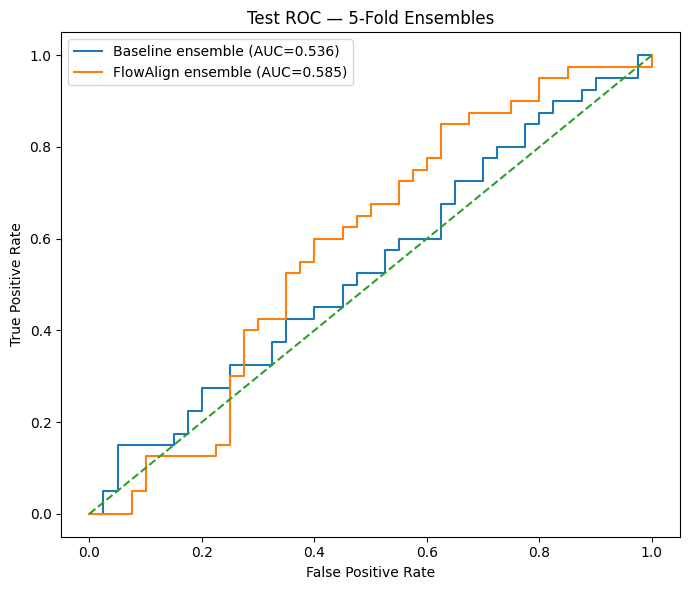

In [46]:
fpr_base, tpr_base, _ = roc_curve(base_test_true, base_test_prob[:, 1])
fpr_flowalign, tpr_flowalign, _ = roc_curve(flowalign_test_true, flowalign_test_prob[:, 1])

plt.figure(figsize=(7, 6))
plt.plot(fpr_base, tpr_base, label=f"Baseline ensemble (AUC={base_test_metrics['roc_auc']:.3f})")
plt.plot(fpr_flowalign, tpr_flowalign, label=f"FlowAlign ensemble (AUC={flowalign_test_metrics['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test ROC — 5-Fold Ensembles")
plt.legend()
plt.tight_layout()

plt.savefig(ENSEMBLE_DIR / "ensemble_test_roc_comparison.png", dpi=200)
plt.show()

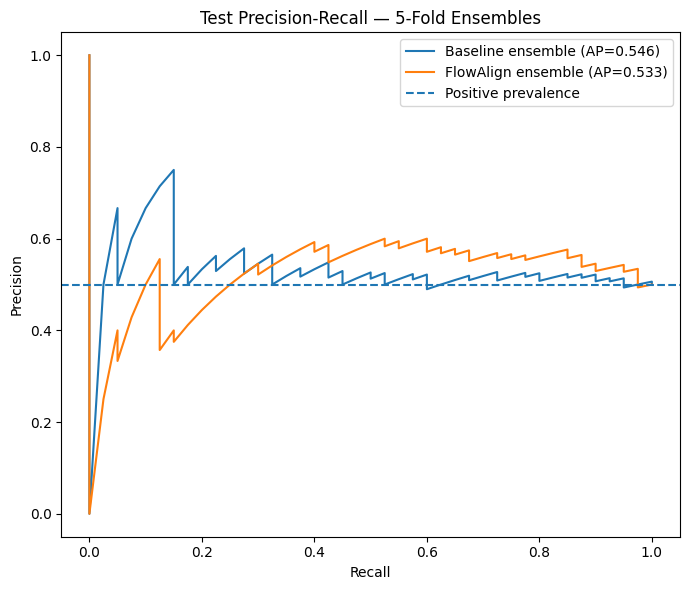

In [47]:
p_base, r_base, _ = precision_recall_curve(base_test_true, base_test_prob[:, 1])
p_flowalign, r_flowalign, _ = precision_recall_curve(flowalign_test_true, flowalign_test_prob[:, 1])

plt.figure(figsize=(7, 6))
plt.plot(r_base, p_base, label=f"Baseline ensemble (AP={base_test_metrics['pr_auc']:.3f})")
plt.plot(r_flowalign, p_flowalign, label=f"FlowAlign ensemble (AP={flowalign_test_metrics['pr_auc']:.3f})")
plt.axhline(np.mean(base_test_true == 1), linestyle="--", label="Positive prevalence")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Test Precision-Recall — 5-Fold Ensembles")
plt.legend()
plt.tight_layout()

plt.savefig(ENSEMBLE_DIR / "ensemble_test_pr_comparison.png", dpi=200)
plt.show()

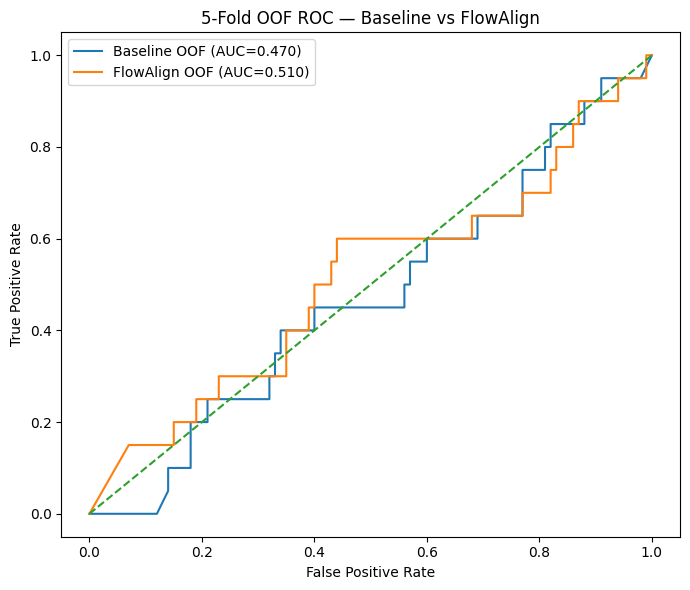

In [48]:
fpr_base, tpr_base, _ = roc_curve(cv_labels, baseline_oof_prob)
fpr_flowalign, tpr_flowalign, _ = roc_curve(cv_labels, flowalign_oof_prob)

auc_base = roc_auc_score(cv_labels, baseline_oof_prob)
auc_flowalign = roc_auc_score(cv_labels, flowalign_oof_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr_base, tpr_base, label=f"Baseline OOF (AUC={auc_base:.3f})")
plt.plot(fpr_flowalign, tpr_flowalign, label=f"FlowAlign OOF (AUC={auc_flowalign:.3f})")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("5-Fold OOF ROC — Baseline vs FlowAlign")
plt.legend()
plt.tight_layout()

plt.savefig(OOF_DIR / "oof_roc_comparison.png", dpi=200)
plt.show()

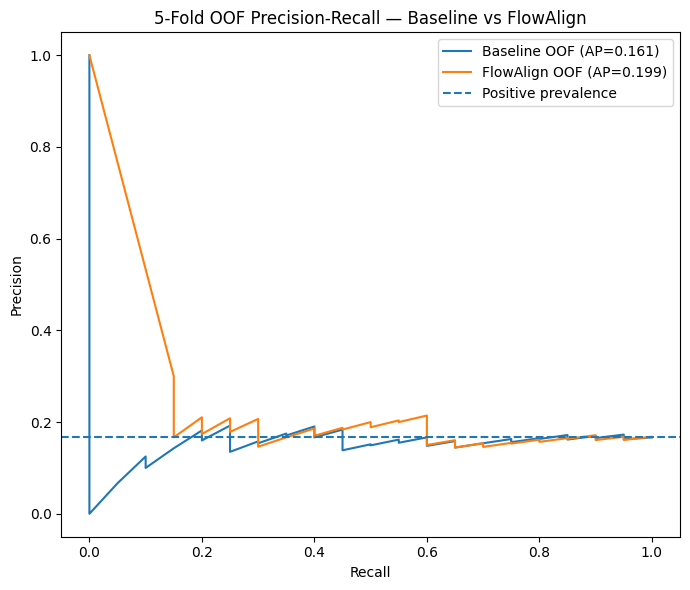

In [49]:
p_base, r_base, _ = precision_recall_curve(cv_labels, baseline_oof_prob)
p_flowalign, r_flowalign, _ = precision_recall_curve(cv_labels, flowalign_oof_prob)

ap_base = average_precision_score(cv_labels, baseline_oof_prob)
ap_flowalign = average_precision_score(cv_labels, flowalign_oof_prob)

plt.figure(figsize=(7, 6))
plt.plot(r_base, p_base, label=f"Baseline OOF (AP={ap_base:.3f})")
plt.plot(r_flowalign, p_flowalign, label=f"FlowAlign OOF (AP={ap_flowalign:.3f})")
plt.axhline(np.mean(cv_labels == 1), linestyle="--", label="Positive prevalence")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("5-Fold OOF Precision-Recall — Baseline vs FlowAlign")
plt.legend()
plt.tight_layout()

plt.savefig(OOF_DIR / "oof_pr_comparison.png", dpi=200)
plt.show()

In [50]:
from scipy.stats import binomtest

base_correct = base_test_pred == base_test_true
flowalign_correct = flowalign_test_pred == base_test_true

base_only = np.sum(base_correct & ~flowalign_correct)
flowalign_only = np.sum(~base_correct & flowalign_correct)

discordant = base_only + flowalign_only

print("Baseline correct / FlowAlign wrong:", base_only)
print("Baseline wrong / FlowAlign correct:", flowalign_only)

if discordant > 0:
    result = binomtest(base_only, n=discordant, p=0.5, alternative="two-sided")
    print("Exact McNemar p-value:", result.pvalue)
    
mcnemar_p_value = result.pvalue if discordant > 0 else 1.0

mcnemar_df = pd.DataFrame([{
    "comparison": "Baseline vs FlowAlign",
    "baseline_only_correct": int(base_only),
    "flowalign_only_correct": int(flowalign_only),
    "discordant": int(discordant),
    "mcnemar_p_value": mcnemar_p_value
}])

mcnemar_df.to_csv(
    ENSEMBLE_DIR / "mcnemar_baseline_vs_flowalign.csv",
    index=False
)

Baseline correct / FlowAlign wrong: 8
Baseline wrong / FlowAlign correct: 5
Exact McNemar p-value: 0.5810546875


In [51]:
from scipy.stats import norm

def delong_components(y_true, y_score):
    y_true, y_score = np.asarray(y_true), np.asarray(y_score)

    pos_scores = y_score[y_true == 1]  
    neg_scores = y_score[y_true == 0]  
    if len(pos_scores) < 2 or len(neg_scores) < 2:
        raise ValueError("DeLong test requires at least two samples from each class.")

    pairwise = (pos_scores[:, None] > neg_scores[None, :]).astype(float)
    pairwise += 0.5 * (pos_scores[:, None] == neg_scores[None, :])

    v10 = pairwise.mean(axis=1)
    v01 = pairwise.mean(axis=0)
    auc = v10.mean()

    return auc, v10, v01


def paired_delong_test(y_true, score_1, score_2):
    y_true = np.asarray(y_true)

    assert len(y_true) == len(score_1) == len(score_2)

    auc_1, v10_1, v01_1 = delong_components(y_true, score_1)
    auc_2, v10_2, v01_2 = delong_components(y_true, score_2)

    n_pos = np.sum(y_true == 1)
    n_neg = np.sum(y_true == 0)

    cov_pos = np.cov(np.vstack([v10_1, v10_2]), ddof=1)
    cov_neg = np.cov(np.vstack([v01_1, v01_2]), ddof=1)
    auc_cov = cov_pos / n_pos + cov_neg / n_neg

    auc_diff = auc_2 - auc_1
    var_diff = auc_cov[0, 0] + auc_cov[1, 1] - 2 * auc_cov[0, 1]
    var_diff = max(var_diff, 0.0)

    if var_diff == 0:
        z = 0.0 if auc_diff == 0 else np.inf
        delong_p_value = 1.0 if auc_diff == 0 else 0.0
    else:
        z = auc_diff / np.sqrt(var_diff)
        delong_p_value = 2 * norm.sf(abs(z))

    return auc_1, auc_2, auc_diff, z, delong_p_value


assert np.array_equal(base_test_true, flowalign_test_true)

base_auc, flowalign_auc, auc_diff, z_stat, delong_p_value = paired_delong_test(
    base_test_true, base_test_prob[:, 1], flowalign_test_prob[:, 1]
)

print("\n===== DELONG TEST: BASELINE vs FLOWALIGN =====")
print(f"Baseline ROC-AUC:  {base_auc:.4f}")
print(f"FlowAlign ROC-AUC: {flowalign_auc:.4f}")
print(f"AUC difference (FlowAlign - Baseline): {auc_diff:+.4f}")
print(f"z-statistic: {z_stat:.4f}")
print(f"p-value: {delong_p_value:.6f}")
print("Result:", "significant ROC-AUC difference (p < 0.05)." if delong_p_value < 0.05 else "no significant ROC-AUC difference (p >= 0.05).")

delong_df = pd.DataFrame([{
    "comparison": "Baseline vs FlowAlign",
    "baseline_auc": base_auc,
    "flowalign_auc": flowalign_auc,
    "auc_difference": auc_diff,
    "z_statistic": z_stat,
    "delong_p_value": delong_p_value
}])
delong_df.to_csv(ENSEMBLE_DIR / "delong_baseline_vs_flowalign.csv", index=False)


===== DELONG TEST: BASELINE vs FLOWALIGN =====
Baseline ROC-AUC:  0.5356
FlowAlign ROC-AUC: 0.5850
AUC difference (FlowAlign - Baseline): +0.0494
z-statistic: 0.5859
p-value: 0.557942
Result: no significant ROC-AUC difference (p >= 0.05).


In [52]:
from scipy.stats import binomtest

cat_mask = base_test_true == 1

base_cat_pred = base_test_pred[cat_mask]
flowalign_cat_pred = flowalign_test_pred[cat_mask]

base_cat_correct = base_cat_pred == 1
flowalign_cat_correct = flowalign_cat_pred == 1

base_cat_recall = base_cat_correct.mean()
flowalign_cat_recall = flowalign_cat_correct.mean()
recall_diff = flowalign_cat_recall - base_cat_recall

base_only_cat = np.sum(base_cat_correct & ~flowalign_cat_correct)
flowalign_only_cat = np.sum(~base_cat_correct & flowalign_cat_correct)
discordant_cats = base_only_cat + flowalign_only_cat

cat_recall_p_value = binomtest(flowalign_only_cat, n=discordant_cats, p=0.5, alternative="two-sided").pvalue if discordant_cats > 0 else 1.0

print("\n===== CAT RECALL TEST: BASELINE vs FLOWALIGN =====")
print(f"Real cats in test set: {cat_mask.sum()}")
print(f"Baseline cat recall:  {base_cat_recall:.4f}")
print(f"FlowAlign cat recall: {flowalign_cat_recall:.4f}")
print(f"Recall difference (FlowAlign - Baseline): {recall_diff:+.4f}")
print(f"Baseline correct / FlowAlign wrong: {base_only_cat}")
print(f"Baseline wrong / FlowAlign correct: {flowalign_only_cat}")
print(f"p-value: {cat_recall_p_value:.6f}")
print("Result:", "significant cat-recall difference (p < 0.05)." if cat_recall_p_value < 0.05 else "no significant cat-recall difference (p >= 0.05).")

cat_recall_df = pd.DataFrame([{
    "comparison": "Baseline vs FlowAlign",
    "n_cats": int(cat_mask.sum()),
    "baseline_cat_recall": base_cat_recall,
    "flowalign_cat_recall": flowalign_cat_recall,
    "recall_difference": recall_diff,
    "baseline_only_correct": int(base_only_cat),
    "flowalign_only_correct": int(flowalign_only_cat),
    "discordant_cats": int(discordant_cats),
    "cat_recall_p_value": cat_recall_p_value
}])
cat_recall_df.to_csv(ENSEMBLE_DIR / "cat_recall_test_baseline_vs_flowalign.csv", index=False)


===== CAT RECALL TEST: BASELINE vs FLOWALIGN =====
Real cats in test set: 40
Baseline cat recall:  0.2250
FlowAlign cat recall: 0.0250
Recall difference (FlowAlign - Baseline): -0.2000
Baseline correct / FlowAlign wrong: 8
Baseline wrong / FlowAlign correct: 0
p-value: 0.007812
Result: significant cat-recall difference (p < 0.05).
